# 附：Codes .{unnumbered}

> Heckman 选择模型配图与模拟数据生成

本 Notebook 用于生成 `06_heckman_lec.ipynb` 调用的模拟数据和配图。运行后会在当前工作路径下生成：

- `./data/heckman_loan_sim.csv`
- `./figs/limit_dep_heckman_fig01_selection_mechanism.png`
- `./figs/limit_dep_heckman_fig02_selected_vs_unselected.png`
- `./figs/limit_dep_heckman_fig03_latent_observed_rate.png`
- `./figs/limit_dep_heckman_fig04_imr_rate.png`
- `./figs/limit_dep_heckman_fig05_ols_heckman_compare.png`
- `./figs/limit_dep_heckman_fig06_exclusion_logic.png`

In [28]:
# ============================================================
# 全局设置
# ============================================================

import os
import platform
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import statsmodels.api as sm
from scipy.stats import norm

warnings.filterwarnings("ignore")

# 创建输出文件夹
os.makedirs("./figs", exist_ok=True)
os.makedirs("./data", exist_ok=True)

# 中文字体设置：Windows 优先使用 SimHei；其他系统尝试常见中文字体
if platform.system() == "Windows":
    FONT_FAMILY = "SimHei"
else:
    import matplotlib.font_manager as fm
    available = {f.name for f in fm.fontManager.ttflist}
    for candidate in ["Noto Sans CJK SC", "Microsoft YaHei", "SimHei", "Arial Unicode MS", "WenQuanYi Micro Hei", "DejaVu Sans"]:
        if candidate in available:
            FONT_FAMILY = candidate
            break
    else:
        FONT_FAMILY = "DejaVu Sans"

plt.rcParams["font.sans-serif"] = [FONT_FAMILY, "DejaVu Sans", "Arial"]
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams.update({
    "font.size": 12,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.22,
    "figure.dpi": 150,
    "savefig.dpi": 220,
    "figure.facecolor": "white"
})

rng = np.random.default_rng(20260428)
print(f"当前使用字体: {FONT_FAMILY}")

当前使用字体: SimHei


In [29]:
# ============================================================
# 生成企业贷款利率与贷款可得性的模拟数据
# ============================================================

n = 3000

# 企业基本特征：变量经过标准化，便于解释模拟参数
size = rng.normal(0, 1, n)                      # 企业规模
cash = rng.normal(0, 1, n)                      # 现金持有
lev = rng.normal(0, 1, n)                       # 杠杆率
profit = rng.normal(0, 1, n)                    # 盈利能力
collateral = 0.45 * size - 0.35 * lev + rng.normal(0, 0.85, n)  # 抵押品充足程度
bank_access = rng.normal(0, 1, n)               # 本地银行服务可得性
credit_window = rng.binomial(1, 1 / (1 + np.exp(-0.25 - 0.25 * size + 0.55 * bank_access)), n)

# 标准化连续变量，便于不同变量尺度接近
raw = pd.DataFrame({
    "size": size,
    "cash": cash,
    "lev": lev,
    "profit": profit,
    "collateral": collateral,
    "bank_access": bank_access,
    "credit_window": credit_window
})

for c in ["size", "cash", "lev", "profit", "collateral", "bank_access"]:
    raw[c] = (raw[c] - raw[c].mean()) / raw[c].std()

# 构造相关误差项：v 影响贷款可得性，u 影响贷款利率
# rho < 0 表示更容易获得贷款的未观测因素，往往伴随更低的未观测信用风险和更低利率
rho = -0.55
sigma_u = 0.75
v = rng.normal(0, 1, n)
eta = rng.normal(0, 1, n)
u = sigma_u * (rho * v + np.sqrt(1 - rho**2) * eta)

# 选择方程：是否获得银行贷款
loan_latent = (
    -0.15
    + 0.50 * raw["size"]
    + 0.18 * raw["cash"]
    - 0.35 * raw["lev"]
    + 0.30 * raw["profit"]
    + 0.55 * raw["collateral"]
    + 0.70 * raw["bank_access"]
    + 0.45 * raw["credit_window"]
    + v
)
loan = (loan_latent > 0).astype(int)

# 结果方程：潜在贷款利率，单位为百分点
rate_latent = (
    6.20
    - 0.35 * raw["size"]
    - 0.12 * raw["cash"]
    + 0.55 * raw["lev"]
    - 0.40 * raw["profit"]
    - 0.25 * raw["collateral"]
    + u
)

# 只有获得贷款的企业才观察到贷款利率
rate = np.where(loan == 1, rate_latent, np.nan)

df = raw.copy()
df["loan_latent"] = loan_latent
df["loan"] = loan
df["rate_latent"] = rate_latent
df["rate"] = rate

# 增加若干原始尺度变量，便于讲义中展示更接近真实数据的直觉
# 这些变量不用于核心模型，只用于描述性展示
df["firm_size_log"] = 22 + 0.9 * df["size"]
df["leverage_ratio"] = np.clip(0.45 + 0.12 * df["lev"], 0.05, 0.95)
df["cash_ratio"] = np.clip(0.20 + 0.08 * df["cash"], 0.01, 0.70)
df["profitability"] = np.clip(0.05 + 0.03 * df["profit"], -0.10, 0.25)

df.to_csv("./data/heckman_loan_sim.csv", index=False)

print("模拟数据已保存: ./data/heckman_loan_sim.csv")
print(f"样本量: {len(df)}")
print(f"获得贷款比例: {df['loan'].mean():.3f}")
print(f"可观测贷款利率样本量: {df['rate'].notna().sum()}")
print(f"观测贷款利率均值: {df['rate'].mean():.3f}")

模拟数据已保存: ./data/heckman_loan_sim.csv
样本量: 3000
获得贷款比例: 0.521
可观测贷款利率样本量: 1563
观测贷款利率均值: 5.544


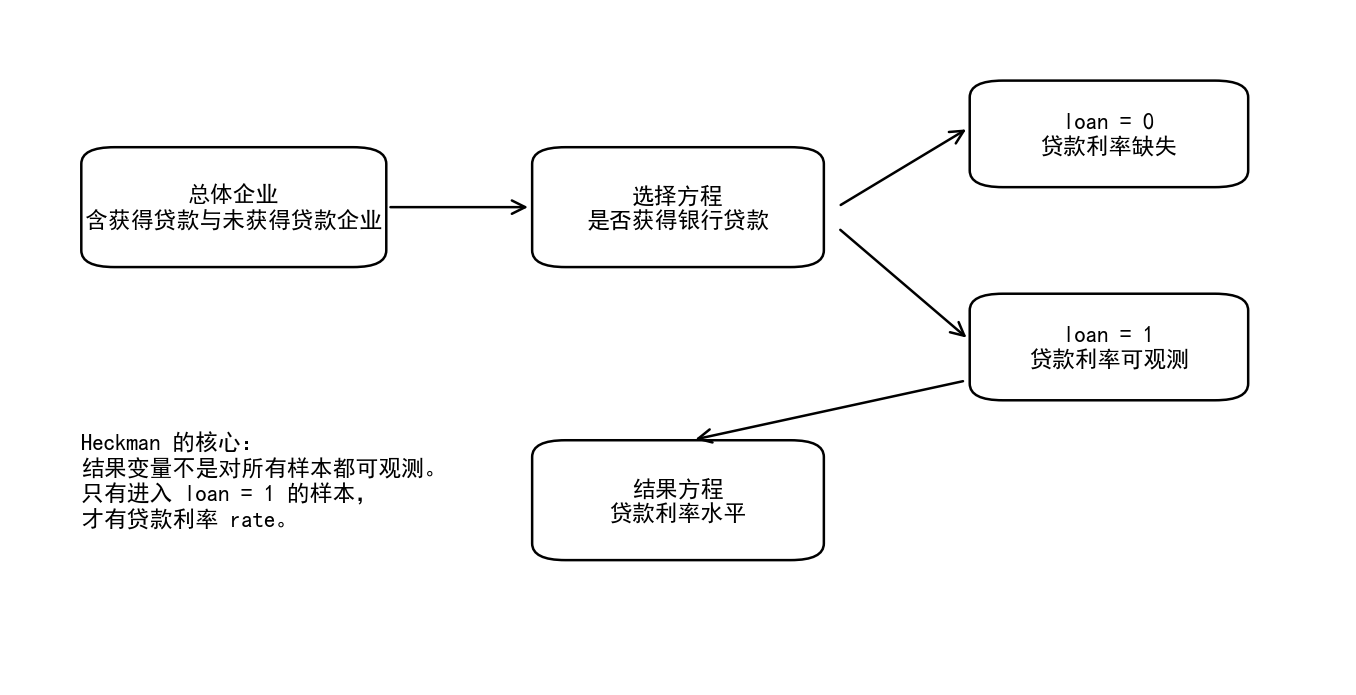

In [45]:
# ============================================================
# 图 1：选择机制与结果观测机制
# ============================================================

fig, ax = plt.subplots(figsize=(9.2, 4.8))
ax.set_axis_off()

boxes = {
    "population": (0.07, 0.64, 0.19, 0.14, "总体企业\n含获得贷款与未获得贷款企业"),
    "selection": (0.41, 0.64, 0.18, 0.14, "选择方程\n是否获得银行贷款"),
    "selected": (0.74, 0.44, 0.17, 0.12, "loan = 1\n贷款利率可观测"),
    "unselected": (0.74, 0.76, 0.17, 0.12, "loan = 0\n贷款利率缺失"),
    "outcome": (0.41, 0.20, 0.18, 0.14, "结果方程\n贷款利率水平")
}

for key, (x, y, w, h, text) in boxes.items():
    box = FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.02,rounding_size=0.025",
        linewidth=1.2,
        edgecolor="black",
        facecolor="white"
    )
    ax.add_patch(box)
    ax.text(x + w/2, y + h/2, text, ha="center", va="center", fontsize=11)

arrows = [
    ((0.28, 0.71), (0.39, 0.71)),
    ((0.62, 0.71), (0.72, 0.83)),
    ((0.62, 0.68), (0.72, 0.51)),
    ((0.718, 0.45), (0.51, 0.36)),
]
for start, end in arrows:
    ax.add_patch(FancyArrowPatch(start, end, arrowstyle="->", mutation_scale=16, linewidth=1.2))

ax.text(
    0.05, 0.30,
    "Heckman 的核心：\n结果变量不是对所有样本都可观测。\n只有进入 loan = 1 的样本，\n才有贷款利率 rate。",
    fontsize=11, ha="left", va="center"
)

fig.tight_layout()
fig.savefig("./figs/limit_dep_heckman_fig01_selection_mechanism.png", bbox_inches="tight")
plt.show()
plt.close(fig)

In [46]:
# ============================================================
# 图 2：获得贷款企业与未获得贷款企业的特征差异
# ============================================================

plot_vars = ["size", "cash", "lev", "profit", "collateral", "bank_access"]
labels = ["企业规模", "现金持有", "杠杆率", "盈利能力", "抵押品", "银行可得性"]
means = df.groupby("loan")[plot_vars].mean().T
means.index = labels

fig, ax = plt.subplots(figsize=(9.2, 4.8))
x = np.arange(len(labels))
width = 0.34
ax.bar(x - width/2, means[0].values, width, label="未获得贷款")
ax.bar(x + width/2, means[1].values, width, label="获得贷款")
ax.axhline(0, linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=0)
ax.set_ylabel("标准化均值")
ax.set_title("获得贷款企业与未获得贷款企业的特征差异")
ax.legend(frameon=False, loc="upper left")
fig.tight_layout()
fig.savefig("./figs/limit_dep_heckman_fig02_selected_vs_unselected.png", bbox_inches="tight")
fig.show()
plt.close(fig)

In [32]:
# ============================================================
# 图 3：潜在贷款利率与观测贷款利率
# ============================================================

fig, ax = plt.subplots(figsize=(8.8, 4.8))
ax.hist(df["rate_latent"], bins=35, alpha=0.45, density=True, label="潜在贷款利率 rate* (所有企业)")
ax.hist(df.loc[df["loan"] == 1, "rate"], bins=35, alpha=0.65, density=True, label="观测贷款利率 rate (loan = 1)")
ax.set_xlabel("贷款利率 (百分点)")
ax.set_ylabel("密度")
ax.set_title("潜在结果与可观测结果的分布差异")
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig("./figs/limit_dep_heckman_fig03_latent_observed_rate.png", bbox_inches="tight")
fig.show()
plt.close(fig)

In [33]:
# ============================================================
# 图 4：Inverse Mills ratio 与贷款利率
# ============================================================

Z = sm.add_constant(df[["size", "cash", "lev", "profit", "collateral", "bank_access", "credit_window"]])
probit_res = sm.Probit(df["loan"], Z).fit(disp=False)
xb = probit_res.predict(linear=True)
df["imr"] = norm.pdf(xb) / np.clip(norm.cdf(xb), 1e-8, 1)

selected = df[df["loan"] == 1].copy()

fig, ax = plt.subplots(figsize=(8.8, 4.8))
ax.scatter(selected["imr"], selected["rate"], s=15, alpha=0.35)
coef = np.polyfit(selected["imr"], selected["rate"], deg=1)
xline = np.linspace(selected["imr"].min(), selected["imr"].max(), 100)
ax.plot(xline, coef[0] * xline + coef[1], linewidth=2)
ax.set_xlabel("Inverse Mills ratio")
ax.set_ylabel("贷款利率 (百分点)")
ax.set_title("选择修正项与观测贷款利率")
fig.tight_layout()
fig.savefig("./figs/limit_dep_heckman_fig04_imr_rate.png", bbox_inches="tight")
fig.show()
plt.close(fig)

In [34]:
# ============================================================
# 图 5：OLS 与 Heckman 两步法的系数对比
# ============================================================

selected = df[df["loan"] == 1].copy()
y = selected["rate"]
X_base = sm.add_constant(selected[["size", "cash", "lev", "profit", "collateral"]])
ols_res = sm.OLS(y, X_base).fit(cov_type="HC1")

X_heck = sm.add_constant(selected[["size", "cash", "lev", "profit", "collateral", "imr"]])
heck2_res = sm.OLS(y, X_heck).fit(cov_type="HC1")

coef_vars = ["size", "cash", "lev", "profit", "collateral"]
coef_df = pd.DataFrame({
    "变量": coef_vars,
    "OLS": [ols_res.params[v] for v in coef_vars],
    "Heckman two-step": [heck2_res.params[v] for v in coef_vars]
})

fig, ax = plt.subplots(figsize=(8.8, 4.8))
x = np.arange(len(coef_vars))
width = 0.34
ax.bar(x - width/2, coef_df["OLS"], width, label="OLS selected sample")
ax.bar(x + width/2, coef_df["Heckman two-step"], width, label="Heckman two-step")
ax.axhline(0, linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(["size", "cash", "lev", "profit", "collateral"])
ax.set_ylabel("系数估计")
ax.set_title("只用被选择样本的 OLS 与 Heckman 两步法对比")
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig("./figs/limit_dep_heckman_fig05_ols_heckman_compare.png", bbox_inches="tight")
fig.show()
plt.close(fig)

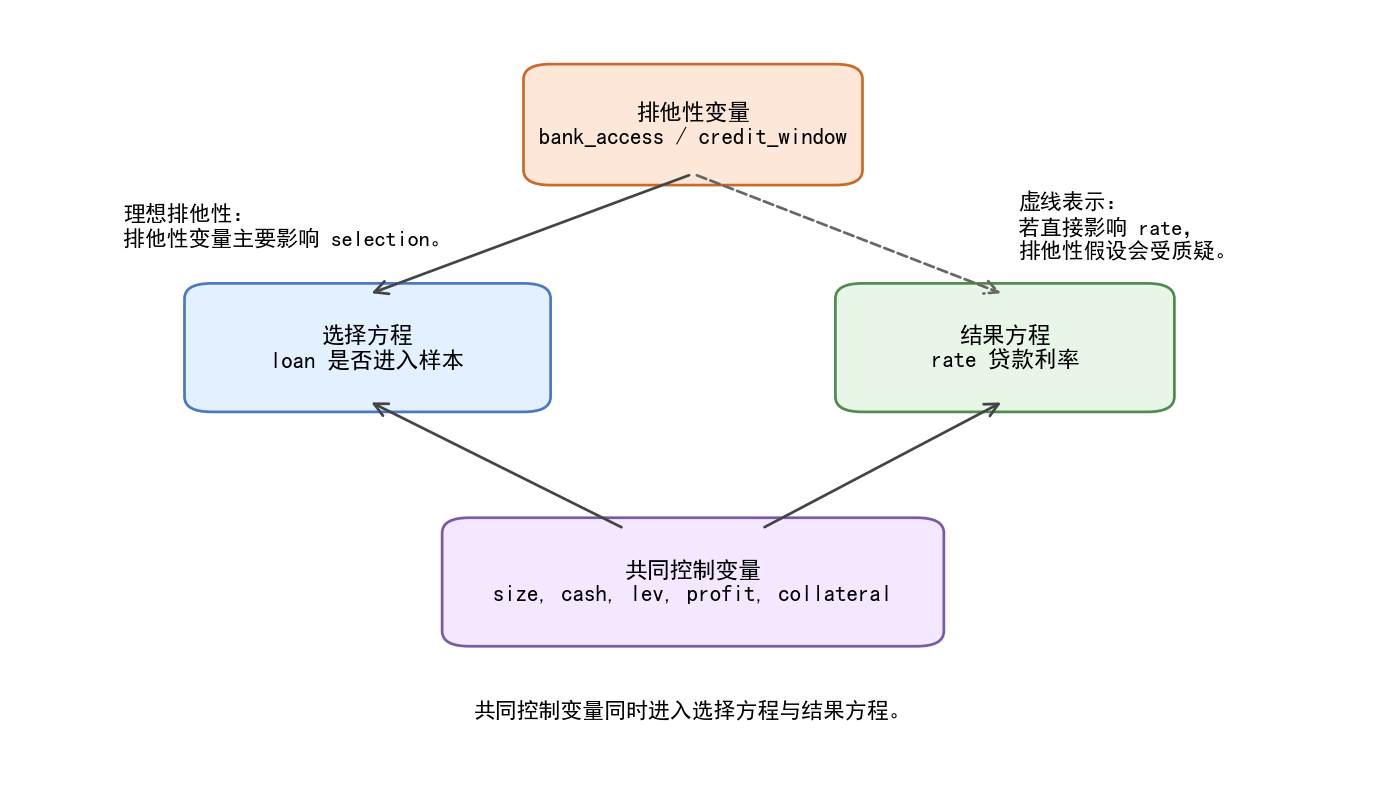

In [35]:
# ============================================================
# 图 6：排他性变量的设定逻辑
# ============================================================

fig, ax = plt.subplots(figsize=(9.4, 5.4))
ax.set_axis_off()
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

items = {
    "excl": (0.39, 0.79, 0.22, 0.13, "排他性变量\nbank_access / credit_window"),
    "select": (0.14, 0.49, 0.24, 0.14, "选择方程\nloan 是否进入样本"),
    "outcome": (0.62, 0.49, 0.22, 0.14, "结果方程\nrate 贷款利率"),
    "controls": (0.33, 0.18, 0.34, 0.14, "共同控制变量\nsize, cash, lev, profit, collateral"),
}

box_styles = {
    "excl": {"facecolor": "#FDE7D9", "edgecolor": "#C96A28"},
    "select": {"facecolor": "#E3F0FF", "edgecolor": "#4A78C2"},
    "outcome": {"facecolor": "#E7F6E7", "edgecolor": "#4F8A4F"},
    "controls": {"facecolor": "#F3E8FF", "edgecolor": "#7A5AA6"},
}

for key, (x, y, w, h, text) in items.items():
    style = box_styles[key]
    box = FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.015,rounding_size=0.02",
        linewidth=1.3,
        edgecolor=style["edgecolor"],
        facecolor=style["facecolor"]
    )
    ax.add_patch(box)
    ax.text(x + w / 2, y + h / 2, text, ha="center", va="center", fontsize=11)

# 第一层 -> 第二层
ax.add_patch(FancyArrowPatch(
    (0.50, 0.79), (0.26, 0.63),
    arrowstyle="->", mutation_scale=16, linewidth=1.3, color="#444444"
))
ax.add_patch(FancyArrowPatch(
    (0.50, 0.79), (0.73, 0.63),
    arrowstyle="->", mutation_scale=16, linewidth=1.3,
    linestyle="--", color="#666666"
))

# 第三层 -> 第二层
ax.add_patch(FancyArrowPatch(
    (0.45, 0.32), (0.26, 0.49),
    arrowstyle="->", mutation_scale=16, linewidth=1.3, color="#444444"
))
ax.add_patch(FancyArrowPatch(
    (0.55, 0.32), (0.73, 0.49),
    arrowstyle="->", mutation_scale=16, linewidth=1.3, color="#444444"
))

ax.text(
    0.08, 0.72,
    "理想排他性：\n排他性变量主要影响 selection。",
    fontsize=10.5, ha="left", va="center"
)
ax.text(
    0.74, 0.72,
    "虚线表示：\n若直接影响 rate，\n排他性假设会受质疑。",
    fontsize=10.5, ha="left", va="center"
)
ax.text(
    0.50, 0.08,
    "共同控制变量同时进入选择方程与结果方程。",
    fontsize=10.5, ha="center", va="center"
)

fig.tight_layout()
fig.savefig("./figs/limit_dep_heckman_fig06_exclusion_logic.png", bbox_inches="tight")
plt.show()
plt.close(fig)

# 运行完成检查

若上述代码顺利运行，当前路径下应出现 `./data/heckman_loan_sim.csv` 和 `./figs/` 中的六张图片。生成上述文件后，即可运行 `06_heckman_lec.ipynb`。